In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import pyranges as pr
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchmetrics import PearsonCorrCoef, R2Score
import torch.nn.functional as F
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning import LightningModule, Trainer
from lightning.pytorch.loggers import WandbLogger
from lightning import LightningModule, LightningDataModule
from torch.utils.data import DataLoader, Dataset
import torch.optim.lr_scheduler as lr_scheduler
import os 
import sys
import itertools
import requests
import matplotlib.pyplot as plt
from tqdm import tqdm, trange
tqdm.pandas()
from sklearn.decomposition import PCA
from scipy.spatial.distance import squareform
import seaborn as sns
import scipy.cluster.hierarchy as hc
from scipy.stats import spearmanr
from importlib import reload
import snapatac2 as snap
from itertools import product
import pychromvar as pc
from pyjaspar import jaspardb
import pickle
import sys
sys.path.append('/scratch/eli')
sys.path.append('/data1/normantm/eli/software')
from perturbseq import *
from sparsepca import *
import multiome as mo # you can skip this if it won't import for version issues

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

In [3]:
# make peak matrix with only the dg50 targets + control

atac = sc.read('/data1/normantm/multiome_collab/RPE1/RPE1_multiome_atac.h5ad')
atac.obs.guide_target = atac.obs.guide_target.str.replace('NKX25', 'NKX2-5').str.replace('NKX31', 'NKX3-1')
multiome_gex = sc.read('/data1/normantm/multiome_collab/RPE1/RPE1_multiome_gex.h5ad')
dg50_gex = sc.read('/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/251204_dg50_gex_raw.h5ad')
tgts = [t.replace('NKX25', 'NKX2-5').replace('NKX31', 'NKX3-1') for t in dg50_gex.obs.guide_target.unique() if "_" not in t]

macs3_dict = {k: v for k, v in atac.uns['macs3'].items() if k in tgts}
assert len(macs3_dict.keys()) == len(tgts)
merged_peaks = snap.tl.merge_peaks(macs3_dict, snap.genome.hg38)
mtx = snap.pp.make_peak_matrix(atac[atac.obs.guide_target.isin(tgts)], use_rep = merged_peaks.to_pandas().Peaks)
mtx = mtx[:, ~mtx.var_names.str.contains('chrY')].copy()

pc.add_peak_seq(mtx, genome_file='/data1/normantm/eli/seq2gex/data/genome/genome.fa', delimiter=":|-")
jdb_obj = jaspardb(release='JASPAR2026')
motifs = jdb_obj.fetch_motifs(
            collection='CORE',
            tax_group=['vertebrates']
)

100%|██████████| 314512/314512 [00:02<00:00, 155887.84it/s]


In [4]:
import MOODS
from anndata import AnnData

def match_motif(data, motifs, cluster_dict: dict, pseudocounts=0.0001, p_value=5e-05, background="even", genome_file: str = None):
    
    adata = data

    assert "peak_seq" in adata.uns_keys(), "Cannot find sequences, please first run add_peak_seq!"
    assert background in ("subject", "genome", "even"), f"'{background}' is not in ('subject', 'genome', 'even')"
    if background == "genome":
        assert os.path.exists(genome_file), f"{genome_file} does not exist!"

    motif_lookup = {m.matrix_id: m for m in motifs}

    cluster_names = list(cluster_dict.keys())
    n_clusters = len(cluster_names)

    adata.uns['motif_name'] = cluster_names
    adata.varm['motif_match'] = np.zeros(shape=(adata.n_vars, n_clusters), dtype=np.float32)

    if background == "subject":
        seq = "".join(adata.uns['peak_seq'][i] for i in range(adata.n_vars))
        _bg = MOODS.tools.bg_from_sequence_dna(seq, 0)
    else:
        _bg = MOODS.tools.flat_bg(4)

    for cluster_idx, cluster_name in enumerate(tqdm(cluster_names)):
        cluster_motif_ids = cluster_dict[cluster_name]
        cluster_motifs = [motif_lookup[mid] for mid in cluster_motif_ids]

        matrices = []
        thresholds = []
        n_cluster_motifs = len(cluster_motifs)

        for motif in cluster_motifs:
            counts = (tuple(motif.counts['A']),
                      tuple(motif.counts['C']),
                      tuple(motif.counts['G']),
                      tuple(motif.counts['T']))
            matrix_fwd = MOODS.tools.log_odds(counts, _bg, pseudocounts)
            matrix_rev = MOODS.tools.reverse_complement(matrix_fwd)
            threshold = MOODS.tools.threshold_from_p(matrix_fwd, _bg, p_value)
            matrices.extend([matrix_fwd, matrix_rev])
            thresholds.extend([threshold, threshold])

        scanner = MOODS.scan.Scanner(7)
        scanner.set_motifs(matrices=matrices, bg=_bg, thresholds=thresholds)

        for peak_idx in range(adata.n_vars):
            results = scanner.scan(adata.uns['peak_seq'][peak_idx])

            hit_scores = {}
            for motif_idx in range(n_cluster_motifs):
                for hit in results[motif_idx * 2]:
                    if hit.pos not in hit_scores or hit.score > hit_scores[hit.pos]:
                        hit_scores[hit.pos] = hit.score
                for hit in results[motif_idx * 2 + 1]:
                    if hit.pos not in hit_scores or hit.score > hit_scores[hit.pos]:
                        hit_scores[hit.pos] = hit.score

            adata.varm['motif_match'][peak_idx, cluster_idx] = sum(hit_scores.values())

    return None

In [ ]:
# deduplicated matches quantified via binding score, see GET (Fu et al. 2025) methods

clusters = pd.read_csv('/data1/normantm/tmn/JASPAR_vertebrates_CORE_flat_metadata.tsv', sep='\t')
clusters['motif_name'] = clusters.matrix_id + '.' + clusters.name
cluster_dict = clusters.groupby('subcluster_ncor_0.7').matrix_id.agg(list).to_dict()
match_motif(mtx, motifs, cluster_dict, background = 'subject')
motif_mtx = pd.DataFrame(mtx.varm['motif_match'], index = mtx.var_names, columns = mtx.uns['motif_name'])

100%|██████████| 404/404 [13:54<00:00,  2.07s/it]


In [6]:
# residualize accessibility in this new peak matrix

pseudobulk = {}
depth = {}
for target in tqdm(tgts):
    cell_mask = mtx.obs['guide_target'] == target
    depth[target] = cell_mask.sum()
    pb = np.asarray(mtx[cell_mask].X.sum(axis=0)).ravel()
    pseudobulk[target] = pb

pb_matrix = pd.DataFrame(pseudobulk, index=mtx.var_names)
depth_series = pd.Series(depth)
pb_per_cell = pb_matrix.div(depth_series, axis=1)

print(f"Pseudobulk matrix: {pb_matrix.shape}")
print(f"Depth range: {depth_series.min()} - {depth_series.max()}")

peak_mean = pb_per_cell.mean(axis=1)
tf_mean = pb_per_cell.mean(axis=0)
global_mean = pb_per_cell.values.mean()

resid_matrix = pb_per_cell.subtract(peak_mean, axis=0).subtract(tf_mean, axis=1) + global_mean
resid_scaled = resid_matrix.div(resid_matrix.std(axis=0), axis=1)

var_explained = 1 - resid_matrix.values.var() / pb_per_cell.values.var()
print(f"Residual matrix: {resid_matrix.shape}")
print(f"Variance explained by additive model: {var_explained:.3f}")
print(f"Residual stats:")
print(f"Mean: {resid_matrix.values.mean():.6f}")
print(f"Std:  {resid_matrix.values.std():.6f}")

res_acc = resid_scaled.sort_index().drop('NTC', axis = 1)

100%|██████████| 51/51 [00:00<00:00, 55.26it/s]


Pseudobulk matrix: (314512, 51)
Depth range: 20 - 2199
Residual matrix: (314512, 51)
Variance explained by additive model: 0.885
Residual stats:
Mean: -0.000000
Std:  0.024380


In [7]:
### create the gene-peak mapping with the 128 nearest overall peaks to each gene in gex matrix
### this is sorted by distance to TSS so positional encoding will be meaningful

regions = pd.read_csv("/data1/normantm/eli/seq2gex/data/genome/engreitz_tss500.bed", comment = '#', sep = '\t')
gex = sc.read('/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/251204_dg50_gex.h5ad')

peaks = pd.DataFrame(index = res_acc.index, columns = ['Chromosome', 'Start', 'End'])
peaks['Chromosome'] = peaks.index.map(lambda i: i.split(':')[0])
peaks['Start'] = peaks.index.map(lambda i: int(i.split(':')[1].split('-')[0]))
peaks['End'] = peaks.index.map(lambda i: int(i.split(':')[1].split('-')[1]))

regions = regions.query("name.isin(@gex.var_names)").rename({'chr': 'Chromosome', 'start': 'Start', 'end': 'End'}, axis = 1)
regions = pr.PyRanges(regions)
peaks = pr.PyRanges(peaks)

peak_map = regions.k_nearest(peaks, 128, nb_cpu = 8).df
peak_map['peak_id'] = peak_map.Chromosome.astype(str) + ':' + peak_map.Start_b.astype(str) + '-' + peak_map.End_b.astype(str)

peak_dict = peak_map.groupby('name').peak_id.apply(lambda g: g.tolist()).to_dict()

import pickle

with open('data/peakdict_dg50only.pkl', 'wb') as f:
    pickle.dump(peak_dict, f)

2026-06-17 18:15:08,186	INFO worker.py:1843 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
2026-06-17 18:15:15,452	INFO worker.py:1843 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


In [9]:
# get new abs_acc

norm_mtx = mtx.X.multiply(10**6 / mtx.obs.n_fragment.values[:, np.newaxis]).tocsr()
abs_acc = pd.DataFrame(norm_mtx.mean(axis = 0).A.flatten(), index = mtx.var_names, columns = ['abs_acc'])
abs_acc

,abs_acc
chr1:9934-10435,0.483244
chr1:181229-181730,1.097951
chr1:180571-181072,0.531653
chr1:267754-268255,0.486021
chr1:585951-586452,0.491105
...,...
chrX:155990729-155991230,0.205356
chrX:155994947-155995448,0.079255
chrX:156002404-156002905,1.239427
chrX:156004240-156004741,1.457033


In [ ]:
# minmax motifs
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()
motif_mtx_scaled = pd.DataFrame(minmax.fit_transform(motif_mtx), index = motif_mtx.index, columns = motif_mtx.columns)

In [11]:
# CRE identity and GC content
# requires this standalone function from multiome.py

import warnings
def label_peaks(peaks, gtf = None):

    """
    Label a dataframe of peaks as strings 'chr:start-end' with the nearest gene and CRE overlap if any.

    Args:
        peaks (pd.DataFrame): DataFrame with 'peak_id' column containing peak strings like 'chr1:1000-2000'.
        gtf (str): Path to gtf file for gene annotations. To label a lot of peaks, provide the gtf file as a pyranges object so it doesn't need to be opened every time.
    Returns:
        reg_mapped (pd.DataFrame): DataFrame mapping each peak to nearest gene and regulatory element.
    """
    
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        
        if 'peak_id' not in peaks.columns or not peaks.peak_id.str.contains(":").all() or not peaks.peak_id.str.startswith("chr").all() or not peaks.peak_id.str.contains("-").all():
            raise ValueError("expects a df with a string like 'chr1:1000-2000' in the 'peak_id' column")
        
        orig_ids = peaks['peak_id'].values.copy()
        peaks[['Chromosome', 'pos']] = peaks.peak_id.str.split(":", expand = True)
        peaks[['Start', 'End']] = peaks.pos.str.split("-", expand = True)
        peaks = pr.PyRanges(peaks.drop("pos", axis = 1))
        
        gtf = pr.read_gtf('/data1/normantm/eli/seq2gex/data/genome/genes.gtf')[["Chromosome", "Feature", "Start", "End", "gene_id", "gene_type", "gene_name"]] if gtf is None else gtf
        gtf = gtf[gtf.Feature == 'gene']
        df_nearest_gene = peaks.nearest(gtf)
        df_nearest_gene = pr.PyRanges(df_nearest_gene.df.drop(["Feature", "Start_b", "End_b", "Strand", 'gene_id', 'gene_type'], axis = 1))

        reg_elements = pd.read_csv("/data1/normantm/eli/seq2gex/data/genome/encodeCcreCombined.bed", sep = '\t', header = None).iloc[:,[0,1,2,12]]
        reg_elements.columns = ["Chromosome", "Start", "End", "reg"]
        reg_elements = reg_elements.query("reg != 'prom'")
        promoters = pd.read_csv("/data1/normantm/eli/seq2gex/data/genome/epdNewHuman006_extended_promoter_regions.bed", sep = '\t', header = None).iloc[:,:3]
        promoters.columns = ["Chromosome", "Start", "End"]
        promoters['reg'] = 'prom'
        reg_elements = pr.PyRanges(pd.concat([reg_elements, promoters], axis = 0))

        reg_mapped = df_nearest_gene.join(reg_elements, how = 'left', report_overlap=True).df.drop(["Start_b", "End_b"], axis = 1)
        reg_mapped = reg_mapped.sort_values(["Overlap"], ascending = False).drop_duplicates('peak_id', keep = 'first')

        reg_mapped['reg'] = reg_mapped.reg.map(lambda r: np.nan if r == '-1' else r).astype(str)
        reg_mapped['edited_peak_annotation'] = reg_mapped.reg.map(lambda a: 'prom' if 'prom' in a else 'enhP' if 'enhP' in a else 'enhD' if 'enhD' in a else 'CTCF' if 'CTCF' in a else 'K4m3' if 'K4m3' in a else np.nan)
        reg_mapped['edited_peak_annotation'] = reg_mapped.apply(lambda df: 'genic_unlabeled' if df.edited_peak_annotation is np.nan and df.Distance == 0 else 'intergenic_unlabeled' if df.edited_peak_annotation is np.nan else df.edited_peak_annotation, axis = 1)

    return reg_mapped.set_index("peak_id").reindex(orig_ids)

feature_mtx = pd.DataFrame(index = mtx.var_names)
feature_mtx['gc'] = [(seq.count('G') + seq.count('C')) / len(seq) for seq in tqdm(mtx.uns['peak_seq'])]
labels = label_peaks(feature_mtx.reset_index().rename({'index': 'peak_id'}, axis = 1))
feature_mtx = feature_mtx.join(pd.get_dummies(labels.edited_peak_annotation).astype(int))
final_mtx = motif_mtx_scaled.join(feature_mtx, how = 'inner')

100%|██████████| 314512/314512 [00:01<00:00, 251270.52it/s]
join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.


In [12]:
### stop here for peak x feature matrix

res_acc.columns = [f'{c}_res_acc' for c in res_acc.columns]
X = final_mtx.join(res_acc, how = 'inner').join(abs_acc, how = 'inner')
X['abs_acc'] = X.abs_acc.astype(np.float32)
X

,Arid5a_sub001,BACH2_sub001,BARX2_sub001,Banp/ZBED1/ZBTB33_sub001,Banp/ZBED1/ZBTB33_sub002,C2H2_ZIC_sub001,C2H2_ZIC_sub002,C2H2_ZIC_sub003,C2H2_ZNF_TLX_sub001,C2H2_ZNF_TLX_sub002,...,BNC2_res_acc,CRX_res_acc,NFATC1_res_acc,SOX13_res_acc,OVOL2_res_acc,KLF4_res_acc,ARID1A_res_acc,NKX2-5_res_acc,GATA2_res_acc,abs_acc
chr1:9934-10435,0.0,0.122048,0.0,0.0,0.0,0.00000,0.113834,0.0,0.000000,0.0,...,0.125192,-0.426173,-0.269082,-0.224795,0.151933,-0.277008,0.929600,-0.147533,-0.320975,0.483244
chr1:181229-181730,0.0,0.122048,0.0,0.0,0.0,0.00000,0.113834,0.0,0.000000,0.0,...,-1.423965,-0.113238,0.218275,-0.669075,-0.081638,1.530642,-0.745157,-0.988193,0.936610,1.097951
chr1:180571-181072,0.0,0.122048,0.0,0.0,0.0,0.00000,0.113834,0.0,0.000000,0.0,...,-0.777082,0.275453,-0.327864,-0.286181,-0.374414,-0.350714,-0.574294,0.581789,0.217070,0.531653
chr1:267754-268255,0.0,0.122048,0.0,0.0,0.0,0.00000,0.113834,0.0,0.000000,0.0,...,-0.320367,-0.453979,0.617477,-0.252187,-0.323327,-0.309897,-0.050446,0.223375,-0.358521,0.486021
chr1:585951-586452,0.0,0.122048,0.0,0.0,0.0,0.00000,0.113834,0.0,0.000000,0.0,...,1.188410,-0.507067,-0.345389,0.617996,-0.401918,1.188041,0.796806,0.124421,-0.430204,0.491105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chrX:155990729-155991230,0.0,0.122048,0.0,0.0,0.0,0.00000,0.113834,0.0,0.000000,0.0,...,-0.341049,-0.226491,-0.080722,-0.028091,0.881636,-0.040826,-0.144207,-0.198070,-0.051352,0.205356
chrX:155994947-155995448,0.0,0.122048,0.0,0.0,0.0,0.00000,0.113834,0.0,0.032424,0.0,...,0.054505,0.535210,-0.082836,-0.030298,0.010128,-0.043476,-0.147885,-0.202247,-0.054377,0.079255
chrX:156002404-156002905,0.0,0.122048,0.0,0.0,0.0,0.05191,0.113834,0.0,0.032424,0.0,...,1.780541,-0.871022,-0.688706,-0.663010,-0.072523,0.757560,0.199349,-0.553979,0.322736,1.239427
chrX:156004240-156004741,0.0,0.122048,0.0,0.0,0.0,0.00000,0.113834,0.0,0.000000,0.0,...,0.699258,-1.040898,0.063839,0.092126,0.110089,-0.223732,0.854885,-0.025145,-1.151015,1.457033


In [ ]:
X.astype(np.float32).to_parquet('data/X_clustered.parquet')

In [ ]:
import anndata as ad
from sklearn.preprocessing import StandardScaler
import pandas as pd
import scanpy as sc

X = pd.read_parquet('data/X_clustered.parquet')
scaler = StandardScaler()
adata = ad.AnnData(X = scaler.fit_transform(X), obs = X.index.to_frame(), var = X.columns.to_frame())
sc.pp.pca(adata, n_comps=128)
sc.pp.neighbors(adata, metric = 'cosine')
sc.tl.umap(adata)
sc.tl.leiden(adata)

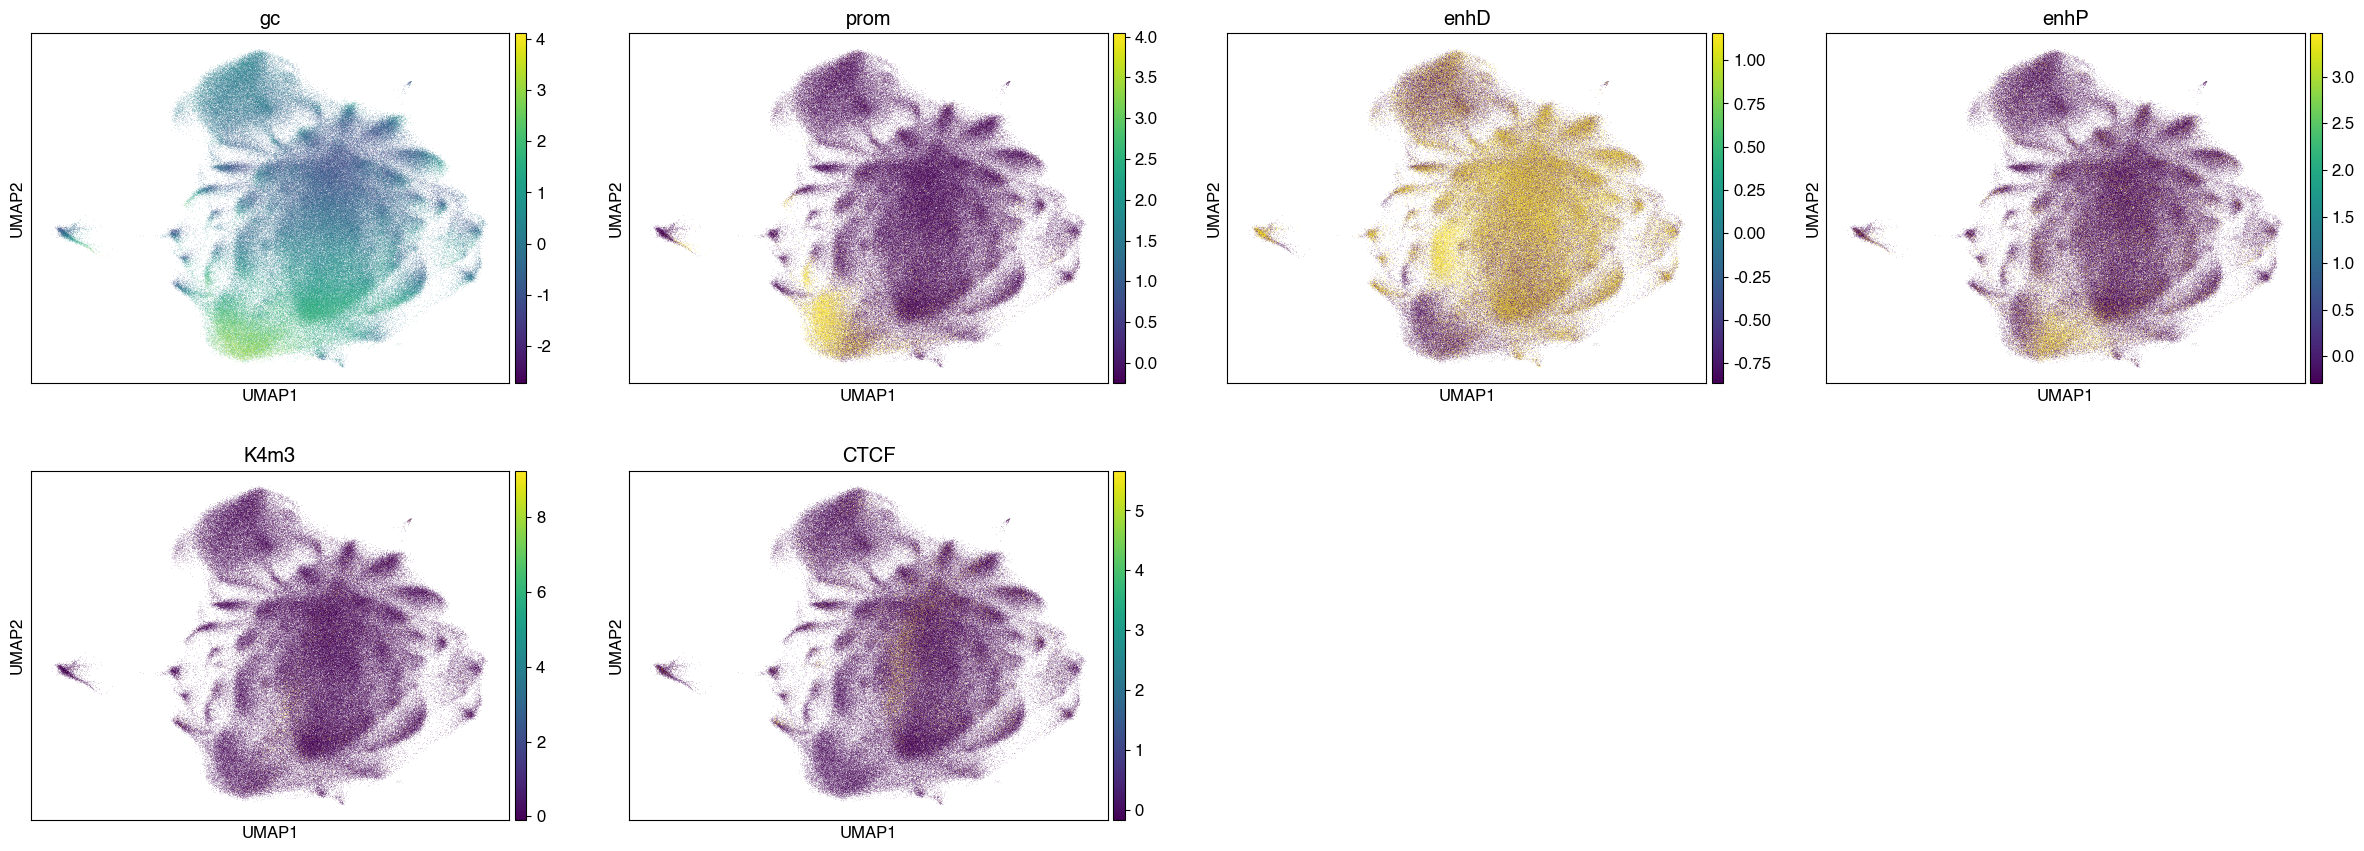

In [8]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

sc.pl.umap(adata, color = ['gc', 'prom', 'enhD', 'enhP', 'K4m3', 'CTCF'], legend_loc = 'on data')

In [ ]:
sc.pl.umap(adata, color = [i for i in X.columns if i.endswith('res_acc')], legend_loc = 'on data', vmin = 0, vmax = 2)

In [15]:
# now collapse to genes, add expression features and weight by correlation to expression in multiome singles
# this relies on the index of mtx_pseudo matching that of gex_pseudo which is why the sort_index() is there

# get correlations
mtx_pseudo = X.filter(like="_res_acc").T
mtx_pseudo.index = mtx_pseudo.index.map(lambda i: i.split("_")[0])
mtx_pseudo.sort_index(inplace = True)

multiome_gex = sc.read('/data1/normantm/multiome_collab/RPE1/RPE1_multiome_gex.h5ad')
multiome_gex.obs.guide_target = multiome_gex.obs.guide_target.str.replace('NKX25', 'NKX2-5').str.replace('NKX31', 'NKX3-1')
dg50_gex = sc.read('/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/251204_dg50_gex_raw.h5ad')
with open('data/peakdict_dg50only.pkl', 'rb') as f:
    peak_dict = pickle.load(f)

gex = multiome_gex[multiome_gex.obs.guide_target.isin(mtx_pseudo.index)]
gex_pseudo = sc.get.aggregate(gex, by = 'guide_target', func = 'mean')
gex_pseudo = pd.DataFrame(gex_pseudo.layers['mean'], index = gex_pseudo.obs_names, columns = gex_pseudo.var_names)
mtx_pseudo = mtx_pseudo.loc[gex_pseudo.index]

corr_dict = {}
peak_dict_inmtx = {k: v for k, v in peak_dict.items() if k in gex_pseudo.columns}
for k, v in tqdm(peak_dict_inmtx.items()):
    expr = gex_pseudo[k]
    corrs = [np.corrcoef(expr, mtx_pseudo[peak])[0,1] for peak in v]
    corr_dict[k] = corrs

# represent each gene as correlation-weighted sum of peak features
rows = {}
for k, v in tqdm(peak_dict_inmtx.items()):
    weights = np.asarray(corr_dict[k])[:, None]
    vals = (X.loc[v].values * weights).sum(axis=0)
    rows[k] = vals

df_genes = pd.DataFrame.from_dict(
    rows,
    orient='index',
    columns=X.columns
)

# join with singles expression from dual guide
dg50_gex = sc.read('/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/251204_dg50_gex_raw.h5ad')
dg50_pseudo = sc.get.aggregate(dg50_gex, by = 'guide_target', func = 'mean')
dg50_pseudo = pd.DataFrame(dg50_pseudo.layers['mean'], index = dg50_pseudo.obs_names, columns = dg50_pseudo.var_names)
df_expr = dg50_pseudo.query("not index.str.contains('_')").T.copy().drop('NTC', axis = 1)
df_expr.columns = [c + "_expr" for c in df_expr.columns]
df_genes = df_genes.join(df_expr, how = 'left')

100%|██████████| 7795/7795 [00:04<00:00, 1619.31it/s]


In [16]:
# expectation was only fit to genes with annotated TSS and not target genes, etc, so we can intersect with the residual csv

resid = pd.read_csv("/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/260506_tvals_expectation_fit.csv", index_col = 0)

common_genes = np.intersect1d(df_genes.index, resid.columns)
df_genes = df_genes.loc[common_genes].copy()

In [17]:
df_genes

,Arid5a_sub001,BACH2_sub001,BARX2_sub001,Banp/ZBED1/ZBTB33_sub001,Banp/ZBED1/ZBTB33_sub002,C2H2_ZIC_sub001,C2H2_ZIC_sub002,C2H2_ZIC_sub003,C2H2_ZNF_TLX_sub001,C2H2_ZNF_TLX_sub002,...,PROP1_expr,PROX1_expr,RUNX3_expr,SOX2_expr,SOX9_expr,SOX13_expr,SOX18_expr,TEAD3_expr,TFAP2A_expr,ZEB2_expr
AAAS,-0.042453,-0.172186,-0.122238,0.024283,0.000000,-0.100496,-0.263081,-0.024865,-0.026887,-0.058022,...,0.089317,0.014707,-0.072437,0.146292,-0.002549,0.040372,0.004804,-0.010247,0.132293,0.174297
AACS,-0.002366,0.480602,0.000000,0.038982,0.000000,-0.003876,0.577559,0.197428,-0.014549,-0.069126,...,0.093747,0.040277,-0.032256,0.088001,-0.036336,0.081476,0.012990,0.037284,0.066498,-0.001498
AAGAB,-0.014031,-0.145657,0.077854,0.026201,0.000000,-0.031256,-0.216411,-0.092237,-0.032371,-0.154740,...,0.017465,-0.000306,-0.058664,0.027869,-0.006373,0.125341,0.057688,-0.008318,-0.042550,-0.016626
AAK1,0.019034,0.139034,0.044170,0.010677,0.000000,0.045944,0.143120,-0.072808,0.050790,-0.099751,...,0.018403,0.036587,-0.054038,-0.030338,-0.012498,0.077650,0.025249,0.002383,-0.031020,0.064761
AAMDC,0.000000,0.791460,0.374668,0.000000,0.026428,0.043599,0.860262,-0.014960,0.200915,-0.088035,...,0.067246,0.115899,-0.018086,0.020595,0.033443,-0.037578,0.056299,-0.039553,0.081722,-0.032172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZWINT,-0.180252,-0.098236,0.356052,0.000000,0.000000,-0.031291,-0.107345,0.034838,-0.096096,-0.117851,...,0.093487,-0.039536,0.068476,0.080793,-0.008421,0.051595,0.190069,0.192617,0.039668,0.125539
ZXDC,-0.022547,0.005809,0.014410,0.000000,0.032625,0.167564,-0.019387,-0.027876,0.021318,-0.036292,...,-0.011373,0.030691,0.039657,0.019174,0.015737,0.046904,0.066395,0.064232,0.002272,0.003855
ZYG11B,0.080379,-0.028418,-0.026755,-0.021377,0.000000,0.044804,0.065251,0.007483,0.056064,-0.030856,...,0.020695,-0.029867,-0.035204,-0.076622,0.043311,0.085544,-0.000518,0.082135,-0.062671,0.062221
ZYX,-0.089191,0.337718,-0.046481,0.000000,0.000000,0.038131,0.287483,0.012267,0.031846,0.143264,...,0.011437,-0.032358,0.063928,0.080343,0.157317,-0.028129,0.037117,-0.049867,0.089150,-0.104273


In [18]:
df_genes.to_parquet('data/df_genes.parquet')